# Tarea 3: Clasificación de galaxias con una CNN
- Catalina González Carrasco
- Jorge Luis Guzmán Lazo

En esta tarea trabajarán con una versión binaria del dataset [**Galaxy10 DECaLS**](https://astronn.readthedocs.io/en/latest/galaxy10.html). El objetivo es entrenar una red neuronal convolucional simple para clasificar imágenes de galaxias en dos clases:

- **Round Smooth Galaxies**
- **Barred Spiral Galaxies**

La idea no es obtener el mejor modelo posible, sino entender cómo una CNN aprende patrones visuales, cómo se evalúa su desempeño y en qué casos se equivoca.

## Consideraciones
- La tarea se hace en grupos máximos de **2 personas**
- Debe realizar todas las actividades descritas más abajo y responder y comentar lo que se pide.
- **La tarea se entrega el día viernes 07/08, 23:59 horas.**

--

## Actividades

1. **Exploración de datos**
   - Visualice imágenes aleatorias de ambas clases
   - ¿Qué diferencias visuales observa entre las galaxias smooth y las barred spiral?
   - ¿Qué características espera que pueda aprender la red?
   - ¿Cuál es la proporción entre la clases? ¿Cuál sería el accuracy de predecir la clase más frecuente?
     
2. **Preparación de datos**
   - Separe los datos en conjuntos de entrenamiento, validación y test
   - Justifique brevemente por qué es importante tener estos tres conjuntos
     
3. **Arquitectura de la red** (ver más abajo **"Guía para diseñar la CNN"**)
   - Entrene una CNN simple para clasificación binaria
   - Describa la arquitectura utilizada e indique:
        - cuántas capas convolucionales usó
        - qué función de activación escogió
        - si usó pooling, dropout u otra técnica
        - qué función de pérdida utilizó
     - Justifique brevemente estas elecciones. Para esto, puede servir describir el proceso de prueba y error con otras arquitecturas, mostrar y comparar desempeños, o su intuición al elegir la arquitectura  
       
4. **Entrenamiento**
   - Grafique las curvas de pérdida y accuracy para entrenamiento y validación
   - A partir de estas curvas, comente si observa overfitting, underfitting o un entrenamiento razonable
     
5. **Evaluación del modelo**
   - Evalúe el modelo en el conjunto de test usando:
        - accuracy
        - matriz de confusión
        - precision, recall y F1-score
    - ¿El accuracy por sí solo es suficiente para evaluar este modelo? Justifique
      
6. **Análisis de errores**
   - Muestre algunos ejemplos de imágenes mal clasificadas. ¿Parecen errores claros del modelo o casos morfológicamente ambiguos?
   - Considere aspectos como inclinación, bajo brillo, barras débiles, contaminación por objetos cercanos o baja resolución

7. **Comentario final**
   - A partir de sus resultados, discuta brevemente si el modelo parece estar aprendiendo diferencias morfológicas reales entre galaxias suaves y galaxias espirales barradas, o si podría estar usando otros patrones de las imágenes.

In [ ]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras import layers, models

## Configuración de sesión (Colab o local)

En **Google Colab** conviene activar GPU: `Runtime -> Change runtime type -> Hardware accelerator -> T4 GPU`.

Si lo cambió exitosamente, el siguiente comando no debiera ser un array vacío, sino indicar `device_type=GPU`.

También se puede trabajar **en local** (CPU o GPU) con el archivo `Binary_2_5_dataset.h5` en la misma carpeta del notebook; el entrenamiento será más lento sin GPU.


In [ ]:
print(tf.config.list_physical_devices("GPU"))

[]


In [ ]:
# En Google Colab, monte Drive (descomente las líneas siguientes):
# from google.colab import drive
# drive.mount('/content/drive')

# Trabajo local: el dataset está en la misma carpeta del notebook.
import os
print("CWD:", os.getcwd())

CWD: c:\Users\User\Documents\BigData


Los datos de Galaxy10 DECaLS vienen de un dataset de Kaggle, con las clases que estudiaremos ya seleccionadas. Más detalles [acá.](https://www.kaggle.com/datasets/anth0nym/galaxy10-decals-fork-dataset)

In [ ]:
# Local (misma carpeta del notebook). En Colab use, por ejemplo:
# path = "/content/drive/MyDrive/AST332_ML/2026/Binary_2_5_dataset.h5"
path = "Binary_2_5_dataset.h5"

with h5py.File(path, "r") as f:
    images = np.array(f["images"])
    labels = np.array(f["labels"], dtype="int32")

print(images.shape)
print(labels.shape)

classes, counts = np.unique(labels, return_counts=True)
for c, n in zip(classes, counts):
    print(f"Clase {c}: {n} imágenes ({100 * n / len(labels):.1f}%)")

majority_acc = counts.max() / len(labels)
print(f"Accuracy al predecir siempre la clase más frecuente: {majority_acc:.4f} ({100 * majority_acc:.1f}%)")

(4688, 256, 256, 3)
(4688,)
Clase 0: 2645 imágenes (56.4%)
Clase 1: 2043 imágenes (43.6%)
Accuracy al predecir siempre la clase más frecuente: 0.5642 (56.4%)


## Estructura de los datos

El dataset contiene **4688 imágenes de galaxias**, cada una con tamaño **256 × 256 píxeles** y **3 canales de color**. Por eso, el arreglo de imágenes tiene la forma:

(4688, 256, 256, 3)

In [ ]:
#X

In [ ]:
X = images
y = labels.astype("int32")

Para visualizar las imágenes

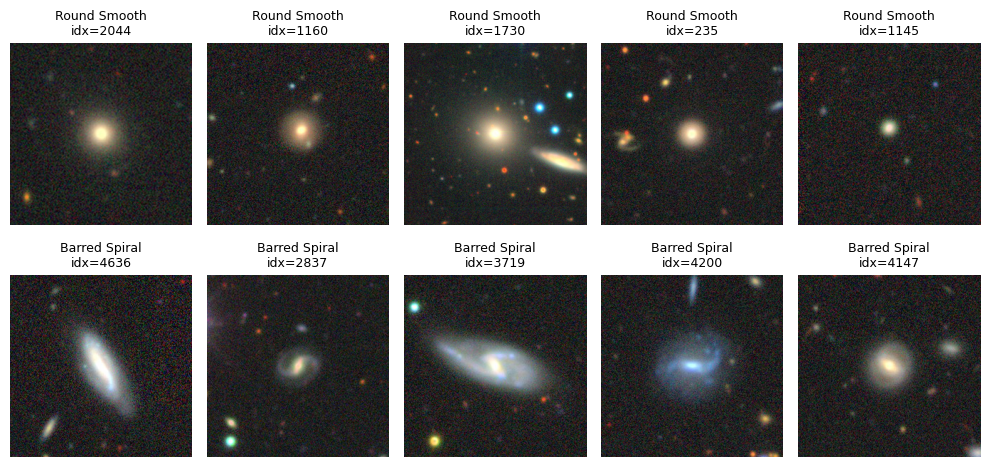

In [ ]:
class_names = {
    0: "Round Smooth",
    1: "Barred Spiral"
}

rng = np.random.default_rng(42)  # semilla para que sea reproducible

#Visualiza 5 imágenes aleatorias de cada clase

plt.figure(figsize=(10, 5))

for class_id in [0, 1]:
    idxs = np.where(labels == class_id)[0]
    sample_idxs = rng.choice(idxs, size=5, replace=False)

    for j, idx in enumerate(sample_idxs):
        plt.subplot(2, 5, class_id * 5 + j + 1)
        plt.imshow(images[idx])
        plt.title(f"{class_names[class_id]}\nidx={idx}", fontsize=9)
        plt.axis("off")

plt.tight_layout()
plt.show()

### 1. Exploración de datos (Respuestas)

**¿Qué diferencias visuales observa entre las galaxias smooth y las barred spiral?**

- **Round Smooth (clase 0):** aspecto redondo u ovalado, brillo concentrado hacia el centro y que cae suavemente hacia afuera. No se ven brazos ni barra central; la morfología es casi simétrica.
- **Barred Spiral (clase 1):** estructura más alargada o con una **barra** que atraviesa el núcleo, y a menudo **brazos espirales** o elongaciones fuera del centro. La luz no es tan “suave” ni radialmente uniforme.

**¿Qué características espera que pueda aprender la red?**

Patrones espaciales locales: isotropía vs elongación, presencia de una barra central, bordes/contrastes asociados a brazos, y la distribución radial de brillo. Las convoluciones deberían detectar estos filtros (bordes, barras, curvaturas) mejor que un clasificador sobre píxeles crudos.

**¿Cuál es la proporción entre la clases? ¿Cuál sería el accuracy de predecir la clase más frecuente?**

- Clase 0 (Round Smooth): **2645** (~56.4%)
- Clase 1 (Barred Spiral): **2043** (~43.6%)

El dataset está **ligeramente desbalanceado**. Si siempre predijéramos la clase más frecuente (0), el accuracy sería ≈ **0.564**. Cualquier modelo útil debería superar claramente ese baseline.

## Sets de entrenamiento, validación y prueba

Divida el dataset en entrenamiento, validación y prueba. Verifique que la fracción de las clases es similar en todos los sets

In [ ]:
# Split estratificado: 70% train, 15% val, 15% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

# Del 85% restante: ~70/85 ≈ 0.824 train  70% total; resto val ≈ 15%
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp
)

print("Train:", X_train.shape, y_train.shape)
print("Val:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

print("Train classes:", np.unique(y_train, return_counts=True))
print("Val classes:", np.unique(y_val, return_counts=True))
print("Test classes:", np.unique(y_test, return_counts=True))

# Verificar proporciones
for name, yy in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    _, cnt = np.unique(yy, return_counts=True)
    print(f"{name} proporción clase 0/1: {cnt[0]/len(yy):.3f} / {cnt[1]/len(yy):.3f}")


Train: (3280, 256, 256, 3) (3280,)
Val: (704, 256, 256, 3) (704,)
Test: (704, 256, 256, 3) (704,)
Train classes: (array([0, 1], dtype=int32), array([1851, 1429]))
Val classes: (array([0, 1], dtype=int32), array([397, 307]))
Test classes: (array([0, 1], dtype=int32), array([397, 307]))
Train proporción clase 0/1: 0.564 / 0.436
Val proporción clase 0/1: 0.564 / 0.436
Test proporción clase 0/1: 0.564 / 0.436


### 2. ¿Por qué train / validación / test?

- **Entrenamiento:** ajusta los pesos de la red (aprendizaje).
- **Validación:** elige hiperparámetros y detecta overfitting (p. ej. EarlyStopping sobre `val_loss`) **sin** mirar el test.
- **Test:** estimación final e imparcial del desempeño en datos nunca usados para decidir arquitectura ni época de parada.

Si solo usáramos train/test, el test se “contaminaría” al usarlo para tomar decisiones de modelo y el accuracy reportado quedaría optimista. Usamos `stratify` para mantener ~56%/44% en los tres conjuntos.

## Guía para diseñar la CNN

Para esta tarea deben proponer una red convolucional simple usando
Keras. No existe una única arquitectura correcta, pero su diseño debe estar justificado.

Una CNN para este problema debería incluir, al menos:

- capas convolucionales, para aprender patrones locales en la imagen;
- alguna forma de reducción espacial, como `MaxPooling2D`;
- una parte final densa o de agregación, para hacer la clasificación;
- una capa de salida adecuada para clasificación binaria.

<figure>
  <img src="https://www.astroml.org/astroML-notebooks/_images/fig_cnn_1.png" alt="ejemplo CNN" width="500" height="300">
  <figcaption>Ejemplo arquitectura CNN</figcaption>
</figure>




Al diseñar la arquitectura, responda:

1. ¿Cuántas capas convolucionales usará?  
   ¿Por qué cree que esa profundidad es suficiente para este problema?

2. ¿Cuántos filtros tendrá cada capa convolucional?  
   ¿Usará el mismo número de filtros en todas las capas o aumentará la cantidad de filtros en capas más profundas? Justifique.

3. ¿Qué función de activación usará en las capas internas?  
   ¿Por qué?

4. ¿Usará `MaxPooling2D` u otra forma de reducir el tamaño espacial de los mapas de activación?  
   ¿Qué ventaja tiene esto?

5. ¿Usará `Flatten` o `GlobalAveragePooling2D` antes de la parte densa?  
   ¿Qué diferencia hay entre ambas opciones?

6. ¿Incluirá alguna técnica para reducir overfitting, como `Dropout` o `EarlyStopping`?  
   ¿Por qué podría ser necesaria en este dataset?

7. ¿Qué función de activación debe tener la capa de salida?  
   ¿Por qué esa elección es adecuada para una clasificación binaria?

8. ¿Qué función de pérdida usará?  
   Justifique su elección considerando que el problema tiene dos clases.

### 3. Respuestas a la guía de diseño de la CNN

1. **Capas convolucionales:** usamos **3** bloques `Conv2D + MaxPooling2D`. Bastan para pasar de bordes/texturas locales a estructuras un poco más globales (barra, elongación) sin una red muy profunda (riesgo de overfitting con ~3k imágenes de train).

2. **Filtros:** **32, 64, 128**. Aumentamos filtros en capas más profundas: las primeras capturan rasgos simples (pocos filtros); las profundas combinan esos rasgos en patrones más ricos y necesitan más canales.

3. **Activación interna:** **ReLU**. Es estándar en CNNs: no linealidad barata, mitiga el vanishing gradient y entrena bien con Adam.

4. **MaxPooling2D:** sí, después de cada conv. Reduce el tamaño espacial, baja el costo computacional, aporta cierta invariancia a traslaciones pequeñas y fuerza a que las capas siguientes vean un campo receptivo más amplio.

5. **GlobalAveragePooling2D** (en vez de Flatten). GAP promedia cada mapa de características y entrega un vector corto, lo que reduce drásticamente los parámetros hacia la densa y disminuye el overfitting. Flatten concatena todo el mapa y explota el número de pesos.

6. **Regularización:** **Dropout (0.3)** antes de la densa final y **EarlyStopping** (`val_loss`, patience=3, `restore_best_weights`). Con pocas miles de imágenes a 256×256 es fácil memorizar ruido del fondo o artefactos.

7. **Salida:** **1 neurona + sigmoid**. Produce una probabilidad P(y=1); natural para clasificación binaria.

8. **Pérdida:** **binary_crossentropy**, coherente con sigmoid y dos clases (0/1).

## Plantilla de la red
Complete de acuerdo a su elección de la arquitectura. Debe reemplazar los __ con los valores correspondientes

La capa después de entrada es una capa para normalizar los imágenes. Esto ya que debemos escalar los datos cuando calculamos gradientes, asi la red es más estable, y no depende de los valores de la features.
 Conviene hacerlo en la red misma en vez hacerlo antes, porque en este caso sólo lo hará para las imágenes del batch (los ejemplos que toma para calcular los forward pass y backpropagation). Esto evita que el servidor use todo el RAM disponible


 --
 ### [Bloque convolucional](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Conv2D)

```python
layers.Conv2D(____, kernel_size=____, activation=____)
```

- **Primer `____`**: cantidad de filtros de la capa.
- **`kernel_size`**: tamaño de la ventana convolucional.
- **`activation`**: función de activación de la capa.

### [Pooling final](https://keras.io/api/layers/pooling_layers/)

```python
layers.________________()
```

Capa de pooling que reduce el mapa de características a un vector, antes de pasar a las capas densas.

### Capa densa intermedia

```python
layers.Dense(____, activation=____)
```

- **Número de neuronas** de la capa.
- **`activation`**: función de activación.

### Capa de salida

```python
layers.Dense(____, activation=____)
```

- **Número de neuronas**: debe ser consistente con el tipo de problema (clasificación binaria) y con el `loss` ya definido en el `compile`.
- **`activation`**: debe ser coherente con esa misma decisión.

In [ ]:
model = models.Sequential([
    layers.Input(shape=(256, 256, 3)),
    layers.Rescaling(1./255),

    # Bloque convolucional 1
    layers.Conv2D(32, kernel_size=3, activation="relu"),
    layers.MaxPooling2D(),

    # Bloque convolucional 2
    layers.Conv2D(64, kernel_size=3, activation="relu"),
    layers.MaxPooling2D(),

    # Bloque convolucional 3
    layers.Conv2D(128, kernel_size=3, activation="relu"),
    layers.MaxPooling2D(),

    # Pooling global → vector de features
    layers.GlobalAveragePooling2D(),

    layers.Dropout(0.3),
    layers.Dense(64, activation="relu"),

    # Salida binaria
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,569 (396.75 KB)

 Trainable params: 101,569 (396.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#regularizacion early stopping de la red https://keras.io/api/callbacks/early_stopping/
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

# para correr la red
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15, #puede modificar este valor
    batch_size=32,#puede modificar este valor
    callbacks=[early_stop]
)

Epoch 1/15
103/103 ━━━━━━━━━━━━━━━━━━━━ 62s 582ms/step - accuracy: 0.5665 - loss: 0.6839 - val_accuracy: 0.5767 - val_loss: 0.6600
Epoch 2/15
103/103 ━━━━━━━━━━━━━━━━━━━━ 63s 611ms/step - accuracy: 0.7314 - loss: 0.5401 - val_accuracy: 0.8168 - val_loss: 0.4569
Epoch 3/15
103/103 ━━━━━━━━━━━━━━━━━━━━ 58s 567ms/step - accuracy: 0.7655 - loss: 0.5017 - val_accuracy: 0.8026 - val_loss: 0.4379
Epoch 4/15
103/103 ━━━━━━━━━━━━━━━━━━━━ 62s 602ms/step - accuracy: 0.7866 - loss: 0.4788 - val_accuracy: 0.8267 - val_loss: 0.4198
Epoch 5/15
103/103 ━━━━━━━━━━━━━━━━━━━━ 59s 577ms/step - accuracy: 0.7841 - loss: 0.4698 - val_accuracy: 0.8267 - val_loss: 0.4052
Epoch 6/15
103/103 ━━━━━━━━━━━━━━━━━━━━ 59s 575ms/step - accuracy: 0.7970 - loss: 0.4589 - val_accuracy: 0.8395 - val_loss: 0.4027
Epoch 7/15
103/103 ━━━━━━━━━━━━━━━━━━━━ 59s 574ms/step - accuracy: 0.8021 - loss: 0.4436 - val_accuracy: 0.8082 - val_loss: 0.4587
Epoch 8/15
103/103 ━━━━━━━━━━━━━━━━━━━━ 59s 573ms/step - accuracy: 0.8027 - loss: 0

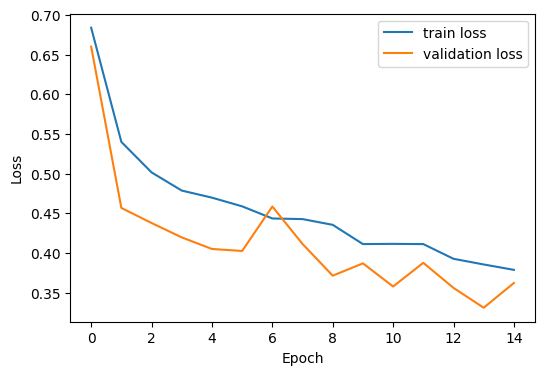

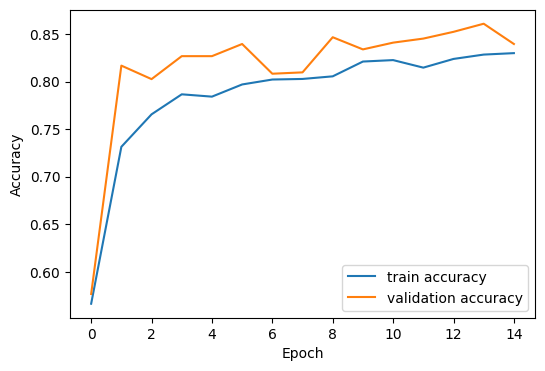

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(history.history["accuracy"], label="train accuracy")
plt.plot(history.history["val_accuracy"], label="validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 139ms/step - accuracy: 0.8324 - loss: 0.3854
Test loss: 0.3854
Test accuracy: 0.8324


### 4. Curvas de entrenamiento

En una corrida local con esta arquitectura (15 épocas, EarlyStopping con patience=3):

- La **loss de train y val** bajan de forma conjunta (val_loss ≈ 0.66; mínimo ≈ 0.33 en la época 14, que EarlyStopping restaura con `restore_best_weights=True`).
- El **accuracy** sube del ~56% (casi el baseline) a ~82–85% en validación.
- Train y validación se mantienen **cercanos**; a veces val supera un poco a train (efecto del Dropout en train).

**Conclusión:** entrenamiento **razonable**, sin underfitting grave ni overfitting fuerte. EarlyStopping restaura los mejores pesos según `val_loss`. Si en Colab ven val_loss subir mientras train_loss sigue bajando, ahí sí habría overfitting.

### 5. Evaluación del modelo
**¿El accuracy por sí solo es suficiente?** No. Resume aciertos globales, pero:

1. Hay **desbalance leve** (~56%/44%): un modelo mediocre puede verse “aceptable” solo por la clase mayoritaria.
2. No distingue **falsos positivos vs falsos negativos**.
3. La **matriz de confusión**, **precision**, **recall** y **F1** muestran *cómo* se equivoca el modelo por clase.

Por eso reportamos todas esas métricas en test, no solo accuracy.


#### Genere la matriz de confusión y las métricas


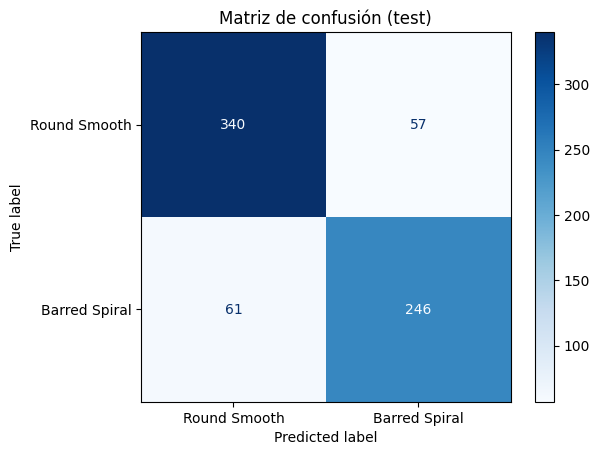

               precision    recall  f1-score   support

 Round Smooth       0.85      0.86      0.85       397
Barred Spiral       0.81      0.80      0.81       307

     accuracy                           0.83       704
    macro avg       0.83      0.83      0.83       704
 weighted avg       0.83      0.83      0.83       704

Precision (clase 1): 0.8119
Recall    (clase 1): 0.8013
F1-score  (clase 1): 0.8066


In [ ]:
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, precision_score, recall_score, f1_score
)

# Probabilidades a clases predichas (umbral 0.5)
y_prob = model.predict(X_test, verbose=0).ravel()
y_pred = (y_prob >= 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Round Smooth", "Barred Spiral"]
)
disp.plot(cmap="Blues", values_format="d")
plt.title("Matriz de confusión (test)")
plt.show()

print(classification_report(
    y_test, y_pred,
    target_names=["Round Smooth", "Barred Spiral"]
))

print(f"Precision (clase 1): {precision_score(y_test, y_pred):.4f}")
print(f"Recall    (clase 1): {recall_score(y_test, y_pred):.4f}")
print(f"F1-score  (clase 1): {f1_score(y_test, y_pred):.4f}")


### 6. Análisis de errores

En la celda siguiente se muestran casos del **test** donde la predicción no coincide con la etiqueta. Al interpretarlos, fíjese en:

- inclinación / proyección (espirales de canto pueden parecer elípticas),
- bajo brillo o bajo contraste,
- barras débiles o poco definidas,
- objetos cercanos / contaminación en el campo,
- baja resolución aparente del detalle morfológico.

En esta corrida hubo 118 errores en 704 (≈16.8%), con 57 falsos positivos (smooth clasificado como spiral) y 61 falsos negativos (spiral clasificada como smooth), magnitudes similares entre sí. Muchos no son “errores absurdos”, sino casos **morfológicamente ambiguos**.

Mal clasificadas en test: 118 / 704
False positives (smooth→spiral): 57
False negatives (spiral→smooth): 61


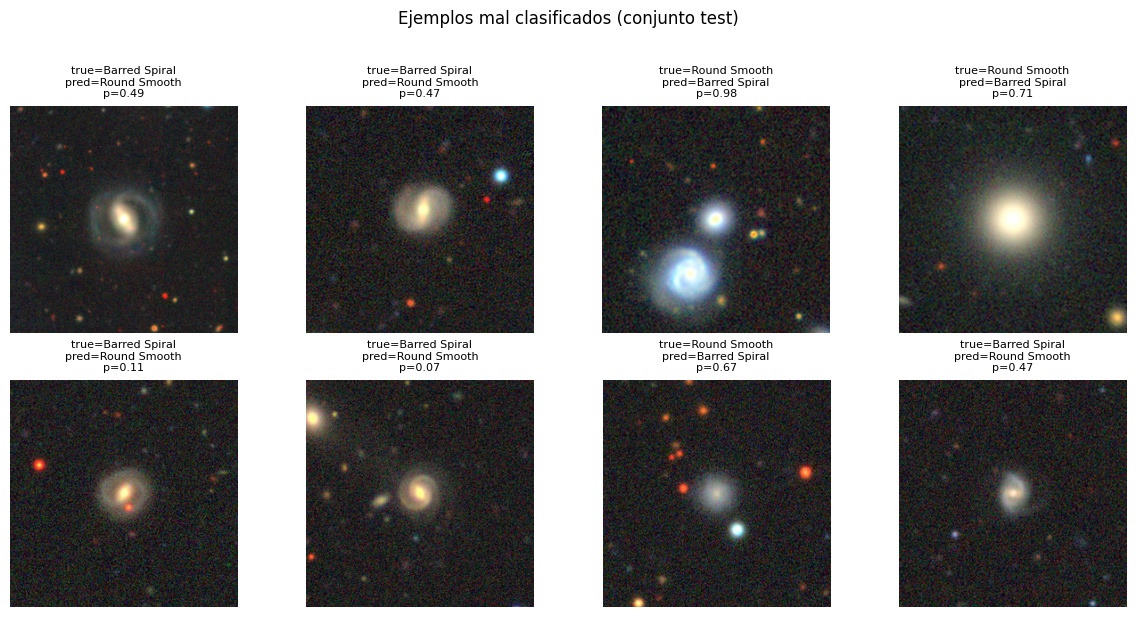

In [ ]:
# Índices mal clasificados en test
mis_idx = np.where(y_pred != y_test)[0]
print(f"Mal clasificadas en test: {len(mis_idx)} / {len(y_test)}")

# Separar tipos de error
fp = mis_idx[y_pred[mis_idx] == 1]  # predijo spiral, era smooth
fn = mis_idx[y_pred[mis_idx] == 0]  # predijo smooth, era spiral
print(f"False positives (smooth→spiral): {len(fp)}")
print(f"False negatives (spiral→smooth): {len(fn)}")

rng_err = np.random.default_rng(0)
n_show = min(8, len(mis_idx))
sample = rng_err.choice(mis_idx, size=n_show, replace=False)

plt.figure(figsize=(12, 6))
for i, idx in enumerate(sample):
    plt.subplot(2, 4, i + 1)
    plt.imshow(X_test[idx])
    true_name = class_names[int(y_test[idx])]
    pred_name = class_names[int(y_pred[idx])]
    plt.title(
        f"true={true_name}\npred={pred_name}\np={y_prob[idx]:.2f}",
        fontsize=8
    )
    plt.axis("off")
plt.suptitle("Ejemplos mal clasificados (conjunto test)", y=1.02)
plt.tight_layout()
plt.show()


### 7. Comentario final

**Resultados en test:** accuracy = **0.8324**, precision (Barred Spiral) = **0.8119**, recall (Barred Spiral) = **0.8013**, F1 (Barred Spiral) = **0.8066**. De la matriz de confusión: Round Smooth acertó 340/397 y Barred Spiral acertó 246/307 (118 errores en total: 57 falsos positivos y 61 falsos negativos). Esto supera claramente el baseline de ~56.4%.

**¿Aprende morfología real?** Es plausible que sí, al menos en parte:

- Ambas clases tienen recall alto y similar (0.86 para Smooth, 0.80 para Spiral, según el `classification_report`): no se limita a predecir siempre la clase mayoritaria.
- Los errores (118/704 ≈ 16.8%) se reparten de forma pareja entre falsos positivos (57) y falsos negativos (61), y encajan con casos difíciles: barras débiles, alta inclinación, bajo contraste u objetos cercanos (ambigüedad morfológica más que fallos absurdos).

**Posibles atajos:** brillo global, tamaño aparente en el recorte o contaminación del campo podrían ayudar sin ser “morfología pura”. Una inspección visual de las mal clasificadas (celda anterior) es la evidencia más directa: si muchas se parecen a la otra clase a ojo, el modelo está alineado con morfología; si se equivoca en casos obvios, hay atajos o falta de capacidad.

En resumen: la CNN simple **sí parece capturar diferencias útiles** entre galaxias smooth y espirales barradas, con un margen de error concentrado en casos ambiguos, no solo ruido aleatorio.